In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
train = pd.read_csv("train(1)(train(1)).csv")
test = pd.read_csv("test2(test(1)).csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (16209, 21)
Test shape: (5404, 20)


In [4]:
train.columns = train.columns.str.lower().str.strip()
test.columns = test.columns.str.lower().str.strip()


In [5]:
# Find price column safely
price_cols = [c for c in train.columns if 'price' in c]

if len(price_cols) == 0:
    raise ValueError("No column containing 'price' found in training data")

TARGET_COL = price_cols[0]
print("Target column used:", TARGET_COL)


Target column used: price


In [6]:
test = test.drop(columns=[TARGET_COL], errors='ignore')


In [7]:
ID_COL = 'id' if 'id' in train.columns else None


In [8]:
NUM_FEATURES = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'condition', 'grade', 'waterfront',
    'view', 'sqft_above', 'sqft_basement',
    'sqft_living15', 'sqft_lot15'
]


In [9]:
missing = [f for f in NUM_FEATURES if f not in train.columns]
if missing:
    raise ValueError(f"Missing columns in train data: {missing}")


In [10]:
X = train[NUM_FEATURES].copy()
y = train[TARGET_COL].copy()

X_test = test[NUM_FEATURES].copy()


In [11]:
X = X.fillna(X.median())
X_test = X_test.fillna(X_test.median())


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_test_scaled = scaler.transform(X_test)


In [13]:
X_train_tab, X_val_tab, y_train, y_val = train_test_split(
    X_scaled,
    y.values,
    test_size=0.2,
    random_state=42
)


In [14]:
np.save("X_train_tab.npy", X_train_tab)
np.save("X_val_tab.npy", X_val_tab)
np.save("y_train.npy", y_train)
np.save("y_val.npy", y_val)
np.save("X_test_tab.npy", X_test_scaled)


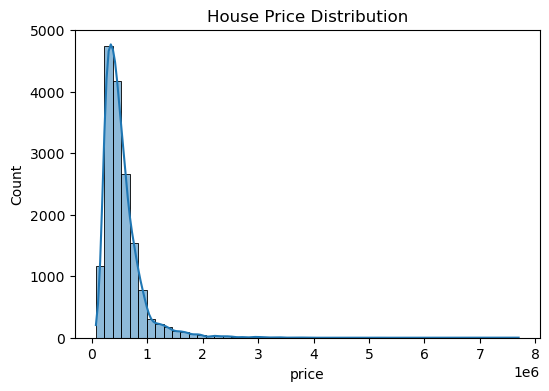

In [15]:
plt.figure(figsize=(6,4))
sns.histplot(y, bins=50, kde=True)
plt.title("House Price Distribution")
plt.show()


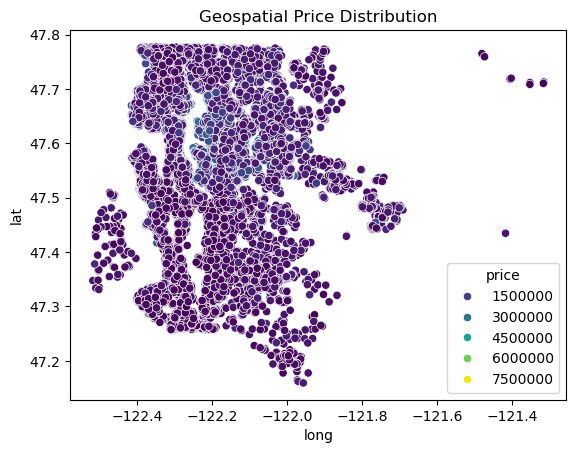

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    x=train['long'], y=train['lat'],
    hue=train['price'], palette='viridis'
)
plt.title("Geospatial Price Distribution")
plt.show()


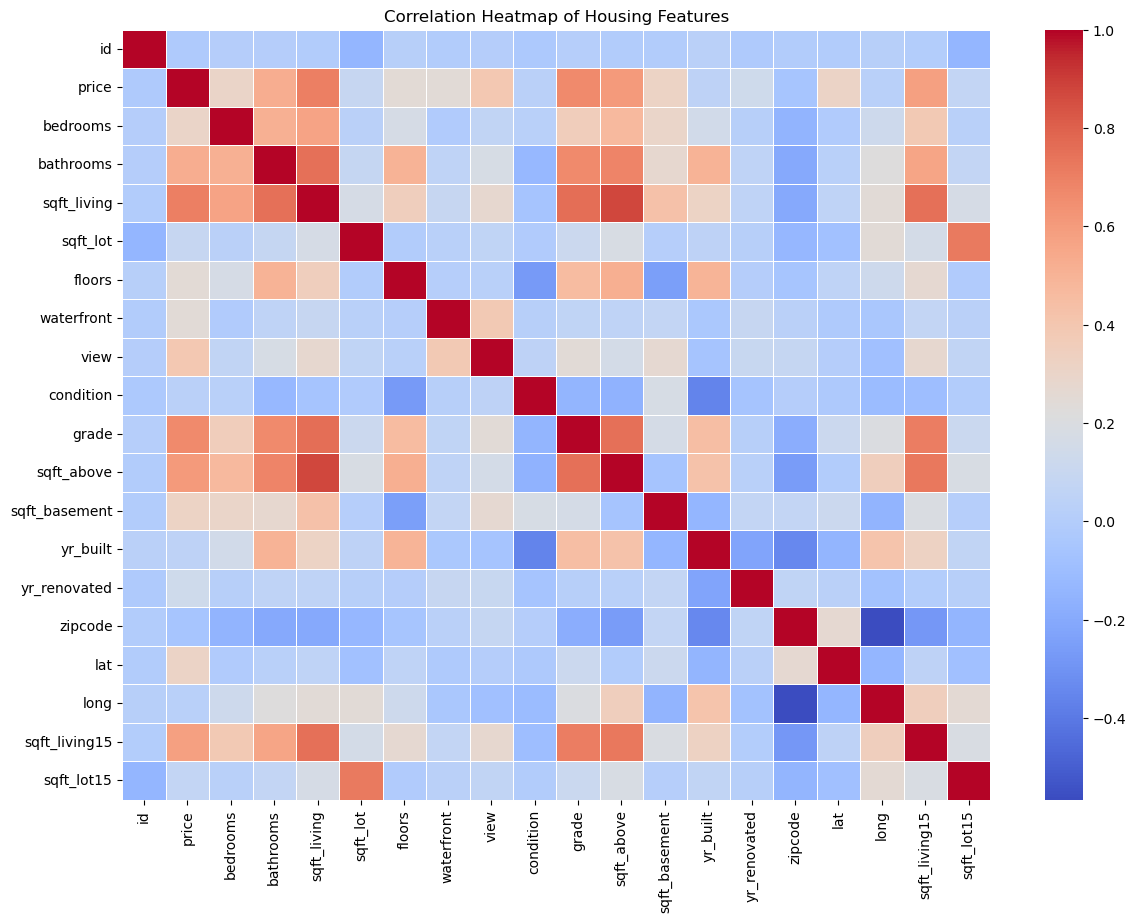

In [22]:
plt.figure(figsize=(14,10))

corr_matrix = train.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Housing Features")
plt.show()


In [17]:
print("Train columns:", train.columns.tolist())
print("Test columns:", test.columns.tolist())
print("Target column:", TARGET_COL)
print("X shape:", X.shape)
print("X_test shape:", X_test.shape)


Train columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Test columns: ['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']
Target column: price
X shape: (16209, 13)
X_test shape: (5404, 13)
